In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Open the dataset

trying to load dictonary from:  /data/vision/beery/scratch/antoine/CBM_reid/data_processing/mara/image_dictionary_optimized.csv
Main image: /archive/vision/beery/animal_reid/datasets/elephants_new/images/earthranger/62420/IMG_6446.JPG


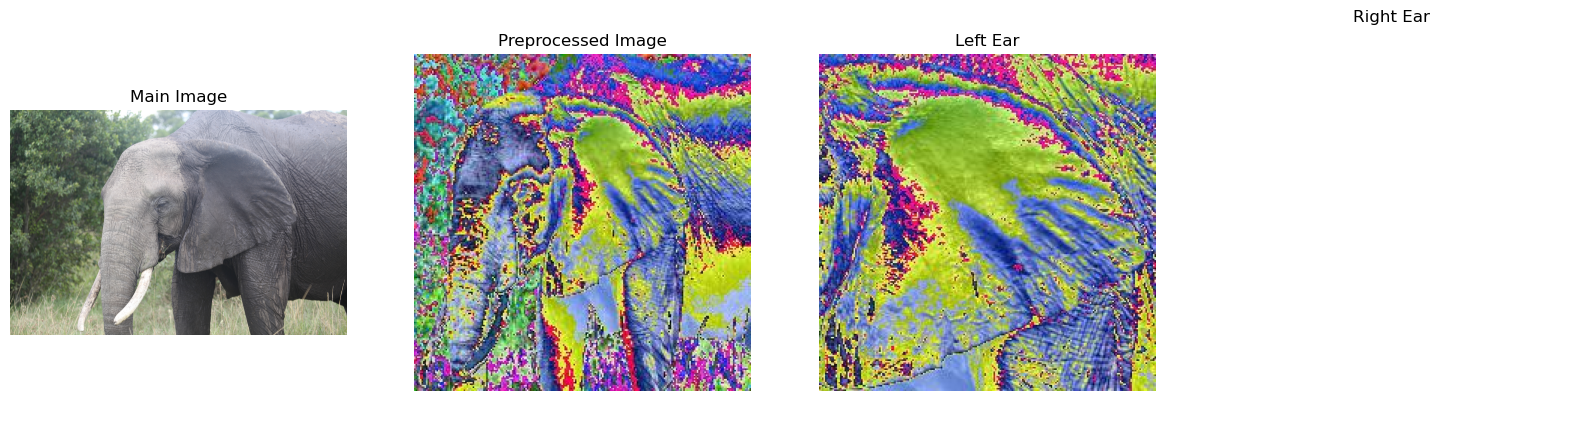

{'subject_id': np.int64(1022), 'ele_id': np.int64(13), 'identified': True, 'subject_SEEK': 'C00T11E____-3344X00S010', 'ele_SEEK': 'C00T11E9990-3344X00S010'}


(<PIL.Image.Image image mode=RGB size=5616x3744>,
 {'subject_id': np.int64(1022),
  'ele_id': np.int64(13),
  'identified': True,
  'subject_SEEK': 'C00T11E____-3344X00S010',
  'ele_SEEK': 'C00T11E9990-3344X00S010'})

In [2]:
mara_dataset = EleHandler(subset='2+encounters', dictonary_path='/data/vision/beery/scratch/antoine/CBM_reid/data_processing/mara/image_dictionary_optimized.csv', dataset_type='mara')

mara_dataset.print_image(1000)

# Split parallel to encounters

In [ ]:
train_indices, test_indices = mara_dataset.split_parallel_to_encounters()

train_subset = Subset(mara_dataset, train_indices)
test_subset = Subset(mara_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

NameError: name 'EleHandler' is not defined

# Computing the CBM on Mara

In [65]:
code ='concept-mara_CBM'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

In [69]:
# Collect embeddings and compute similarity matrix
query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1, 5, 10, 20, 100]}
for k in [1, 5, 10, 20, 100]: print(f"Recall@{k}: {test_recalls[k] * 100:.2f}%")

  0%|          | 0/267 [00:00<?, ?it/s]

100%|██████████| 290/290 [06:11<00:00,  1.28s/it]


Recall@1: 46.09%
Recall@5: 62.34%
Recall@10: 69.79%
Recall@20: 74.44%
Recall@100: 86.32%


In [71]:
import torch

print(f'We have {query_labels.unique().shape[0]} unique elephants in the query set and {gallery_labels.unique().shape[0]} unique elephants in the gallery set.')
print(f'From the query set { query_labels.unique().shape[0] - torch.sum(torch.isin(query_labels.unique(), gallery_labels.unique()))} elephants are not present in the gallery set.')
print(f'From the gallery set { gallery_labels.unique().shape[0] - torch.sum(torch.isin(gallery_labels.unique(), query_labels.unique()))} elephants are not present in the query set.')

We have 531 unique elephants in the query set and 531 unique elephants in the gallery set.
From the query set 0 elephants are not present in the gallery set.
From the gallery set 0 elephants are not present in the query set.


# Finetuning MegaDescriptor for Mara on top of the finetuning on the bostwana elephants

In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
code ='MARA_2+_FINETUNING'

mara_dataset = EleHandler(subset='2+encounters', dictonary_path='/data/vision/beery/scratch/antoine/CBM_reid/data_processing/mara/image_dictionary_optimized.csv', dataset_type='mara')
train_indices, test_indices = mara_dataset.split_parallel_to_encounters()

train_subset = Subset(mara_dataset, train_indices)
test_subset = Subset(mara_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=True)

MD_finetuned = Backbone(model_name="MegaDescriptor", experiment_code=code, lr=5e-6, num_classes=len(mara_dataset.ele_id_to_label))
MD_finetuned.train(train_loader, test_loader, num_epochs=50)
MD_finetuned.test(train_loader, test_loader)

trying to load dictonary from:  /data/vision/beery/scratch/antoine/CBM_reid/data_processing/mara/image_dictionary_optimized.csv
Single encounter elephants: 0, indices: 0


TOTAL - Train indices: 19670, Test indices: 15948


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Backbone parameters require gradients: True


KeyboardInterrupt: 